In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## Get am+loftee correlations

In [2]:
# Configuration and paths
corr_method = 'pearson'
trait_type = 'quantitative'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac


759.292

In [3]:
appv = pl.read_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6coding_PRScorr.parquet")
appv = appv.filter(pl.col('n_individuals')<=mac)
appv

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value
str,str,u32,f32,f32
"""chr1:3476029:G:A""","""red_blood_cell_erythrocyte_dis…",19,-0.347493,0.960577
"""chr1:2229460:C:T""","""red_blood_cell_erythrocyte_dis…",1,0.426851,null
"""chr1:10072146:G:A""","""red_blood_cell_erythrocyte_dis…",22,-0.12495,0.843646
"""chr1:3463318:G:A""","""mean_platelet_thrombocyte_volu…",128,-0.015066,0.846027
"""chr1:2515618:C:T""","""mean_platelet_thrombocyte_volu…",98,0.011947,0.797165
…,…,…,…,…
"""chr22:50454662:G:A""","""microalbumin_in_urine_int""",1,-0.803816,null
"""chr22:50455057:C:G""","""mothers_age_at_death_int""",1,1.928162,null
"""chr22:50283981:T:C""","""mothers_age_at_death_int""",1,1.303833,null


In [4]:
alof = pl.read_parquet("/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag/annotations.parquet", columns=['id', 'region', 'loftee_hc', 'am_pathogenicity']).with_columns(
    am_loftee = (pl.col('loftee_hc') + pl.col('am_pathogenicity')).cast(pl.Float32)
)#.drop(['loftee_hc', 'am_pathogenicity'])
alof

id,region,loftee_hc,am_pathogenicity,am_loftee
str,str,i8,f64,f32
"""chr1:169795116:G:C""","""ENSG00000000460""",0,0.0,0.0
"""chr1:169798959:G:A""","""ENSG00000000460""",0,0.0,0.0
"""chr1:169798959:G:C""","""ENSG00000000460""",0,0.0,0.0
"""chr1:169798959:G:GT""","""ENSG00000000460""",0,0.0,0.0
"""chr1:169798959:G:T""","""ENSG00000000460""",0,0.0,0.0
…,…,…,…,…
"""chr7:151061966:C:T""","""ENSG00000288608""",0,0.0,0.0
"""chr7:151061967:GA:G""","""ENSG00000288608""",1,0.0,1.0
"""chr7:151061968:A:G""","""ENSG00000288608""",0,0.0,0.0


In [5]:
alof['region'].value_counts(sort=True)

region,count
str,u64
"""ENSG00000143631""",9263
"""ENSG00000008710""",8573
"""ENSG00000081853""",8384
"""ENSG00000178209""",8265
"""ENSG00000151914""",7460
…,…
"""ENSG00000072694""",73
"""ENSG00000164032""",67
"""ENSG00000162188""",59


In [6]:
gnames = pl.read_csv('/home/dnanexus/data_dir/gnomad.v4.1.constraint_metrics.tsv',
    separator='\t',
    null_values=['.', 'NA'],
).filter(
    pl.col('transcript_type') == 'protein_coding'
).select(['gene', 'gene_id']).unique().rename({
    'gene': 'gene_name',
    'gene_id': 'region'
}).drop_nulls()

gnames

gene_name,region
str,str
"""CFD""","""ENSG00000197766"""
"""DPPA5""","""ENSG00000203909"""
"""GPC1""","""ENSG00000063660"""
"""ABI3BP""","""ENSG00000154175"""
"""ARPP21""","""ENSG00000172995"""
…,…
"""RSC1A1""","""ENSG00000215695"""
"""AGAP1""","""ENSG00000157985"""
"""NKX2-2""","""ENSG00000125820"""


In [7]:
alof_gp = appv.join(alof, on='id', how='inner').join(gnames, on='region', how='left').sort('n_individuals', descending=True)
alof_gp

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,region,loftee_hc,am_pathogenicity,am_loftee,gene_name
str,str,u32,f32,f32,str,i8,f64,f32,str
"""chr1:1793247:C:T""","""heel_bone_mineral_density_bmd_…",759,0.004783,0.877477,"""ENSG00000078369""",0,0.0,0.0,"""GNB1"""
"""chr1:17354601:G:A""","""age_started_wearing_glasses_or…",759,-0.011846,0.987002,"""ENSG00000159339""",0,0.0,0.0,"""PADI4"""
"""chr1:20350923:C:T""","""hdl_cholesterol_int""",759,-0.03964,0.82771,"""ENSG00000158816""",0,0.0,0.0,"""VWA5B1"""
"""chr1:20350923:C:T""","""calcium_int""",759,-0.051629,0.969885,"""ENSG00000158816""",0,0.0,0.0,"""VWA5B1"""
"""chr1:20350923:C:T""","""albumin_int""",759,-0.01811,0.90053,"""ENSG00000158816""",0,0.0,0.0,"""VWA5B1"""
…,…,…,…,…,…,…,…,…,…
"""chr22:50454662:G:A""","""microalbumin_in_urine_int""",1,-0.803816,null,"""ENSG00000100241""",0,0.0,0.0,"""SBF1"""
"""chr22:50455057:C:G""","""mothers_age_at_death_int""",1,1.928162,null,"""ENSG00000100241""",0,0.0,0.0,"""SBF1"""
"""chr22:50283981:T:C""","""mothers_age_at_death_int""",1,1.303833,null,"""ENSG00000196576""",0,0.9855,0.9855,"""PLXNB2"""


In [8]:
alof_gp['region'].value_counts(sort=True)

region,count
str,u64
"""ENSG00000008710""",701109
"""ENSG00000178209""",700291
"""ENSG00000143631""",670563
"""ENSG00000081853""",603895
"""ENSG00000103335""",551699
…,…
"""ENSG00000164032""",4659
"""ENSG00000224389""",4150
"""ENSG00000231852""",4150


In [9]:
# 1. Aggregate to get correlation (r) and number of pairs (n)
lofcorr_df = (
    alof_gp.lazy()
    .group_by(["region", "gene_name", "phenotype"])
    .agg(
        n_variants=pl.col("id").count(),
        n_plof=pl.col("loftee_hc").sum(),
        n_variants_nonull=(pl.col("mean_pheno_value").is_not_null() & pl.col("am_loftee").is_not_null()).sum(),
        am_loftee_corr=pl.corr("mean_pheno_value", "am_loftee"),
        loftee_corr=pl.corr("mean_pheno_value", "loftee_hc"),
        n_individuals_var=pl.col("n_individuals").filter(pl.col("am_loftee") > 0),
        n_individuals_plof=pl.col("n_individuals").filter(pl.col("loftee_hc") == 1),
    )
    .filter(
        (pl.col("n_variants_nonull") > 2) &
        (pl.col("n_plof") > 0)
    )  
    
    # 2. Compute the t-statistic and p-value on the aggregated results
    .with_columns(
        plof_prop = pl.col('n_plof')/pl.col('n_variants_nonull'),
        am_loftee_prop = pl.col('n_individuals_var')/pl.col('n_variants_nonull'),
        # Calculate the t-statistic from r and n
        t_stat=pl.col("am_loftee_corr") * ((pl.col("n_variants_nonull") - 2) / (1 - pl.col("am_loftee_corr")**2))**0.5,
    )
    .with_columns(
        # Calculate the two-tailed p-value from the t-statistic
        p_value=pl.struct(["t_stat", "n_variants_nonull"]).map_elements(
            lambda x: (
                stats.t.sf(np.abs(x["t_stat"]), df=x["n_variants_nonull"] - 2) * 2
                if x["t_stat"] is not None else None
            ),
            return_dtype=pl.Float64
        )
    )
).collect(engine='streaming')

lofcorr_df.write_parquet("/home/dnanexus/data_dir/association_files/am_loftee_correlation_quantitative_EUR_genebass1e6coding_maf1e3.parquet")
lofcorr_df

region,gene_name,phenotype,n_variants,n_plof,n_variants_nonull,am_loftee_corr,loftee_corr,n_individuals_var,n_individuals_plof,plof_prop,am_loftee_prop,t_stat,p_value
str,str,str,u64,i64,u64,f32,f32,list[u32],list[u32],f64,list[f64],f64,f64
"""ENSG00000144191""","""CNGA3""","""trunk_fat_percentage_int""",630,38,630,0.016501,-0.059771,"[728, 620, … 1]","[49, 42, … 1]",0.060317,"[1.155556, 0.984127, … 0.001587]",0.413563,0.679335
"""ENSG00000179364""","""PACS2""","""reticulocyte_count_int""",792,29,792,-0.006069,0.025805,"[449, 227, … 1]","[8, 3, … 1]",0.036616,"[0.566919, 0.286616, … 0.001263]",-0.170582,0.864596
"""ENSG00000084734""","""GCKR""","""body_mass_index_bmi_impedance_…",509,50,509,0.01658,0.036507,"[460, 313, … 1]","[460, 59, … 1]",0.098232,"[0.903733, 0.614931, … 0.001965]",0.373376,0.709025
"""ENSG00000149782""","""PLCB3""","""mothers_age_at_death_int""",772,31,772,0.009311,0.043068,"[161, 145, … 1]","[4, 3, … 1]",0.040155,"[0.208549, 0.187824, … 0.001295]",0.258374,0.796187
"""ENSG00000142453""","""CARM1""","""aspartate_aminotransferase_int""",399,17,399,-0.053408,0.00418,"[99, 54, … 1]","[5, 2, … 1]",0.042607,"[0.24812, 0.135338, … 0.002506]",-1.065674,0.287219
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000153531""","""ADPRHL1""","""white_blood_cell_leukocyte_cou…",1394,28,1394,0.034529,0.006016,"[359, 177, … 1]","[50, 37, … 1]",0.020086,"[0.257532, 0.126973, … 0.000717]",1.289029,0.197602
"""ENSG00000128567""","""PODXL""","""age_at_hysterectomy_int""",144,5,144,0.049536,-0.04295,"[440, 246, … 1]","[34, 1, … 1]",0.034722,"[3.055556, 1.708333, … 0.006944]",0.591015,0.55545
"""ENSG00000104879""","""CKM""","""peak_expiratory_flow_pef_int""",438,27,438,0.008442,0.012971,"[204, 198, … 1]","[24, 15, … 1]",0.061644,"[0.465753, 0.452055, … 0.002283]",0.176277,0.860158


## Compare gene-phenotype associations between burden-test and correlation

In [10]:
lofcorr_df = pl.read_parquet("/home/dnanexus/data_dir/association_files/am_loftee_correlation_quantitative_EUR_genebass1e6coding_maf1e3.parquet")
lofcorr_df

region,gene_name,phenotype,n_variants,n_plof,n_variants_nonull,am_loftee_corr,loftee_corr,n_individuals_var,n_individuals_plof,plof_prop,am_loftee_prop,t_stat,p_value
str,str,str,u64,i64,u64,f32,f32,list[u32],list[u32],f64,list[f64],f64,f64
"""ENSG00000144191""","""CNGA3""","""trunk_fat_percentage_int""",630,38,630,0.016501,-0.059771,"[728, 620, … 1]","[49, 42, … 1]",0.060317,"[1.155556, 0.984127, … 0.001587]",0.413563,0.679335
"""ENSG00000179364""","""PACS2""","""reticulocyte_count_int""",792,29,792,-0.006069,0.025805,"[449, 227, … 1]","[8, 3, … 1]",0.036616,"[0.566919, 0.286616, … 0.001263]",-0.170582,0.864596
"""ENSG00000084734""","""GCKR""","""body_mass_index_bmi_impedance_…",509,50,509,0.01658,0.036507,"[460, 313, … 1]","[460, 59, … 1]",0.098232,"[0.903733, 0.614931, … 0.001965]",0.373376,0.709025
"""ENSG00000149782""","""PLCB3""","""mothers_age_at_death_int""",772,31,772,0.009311,0.043068,"[161, 145, … 1]","[4, 3, … 1]",0.040155,"[0.208549, 0.187824, … 0.001295]",0.258374,0.796187
"""ENSG00000142453""","""CARM1""","""aspartate_aminotransferase_int""",399,17,399,-0.053408,0.00418,"[99, 54, … 1]","[5, 2, … 1]",0.042607,"[0.24812, 0.135338, … 0.002506]",-1.065674,0.287219
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000153531""","""ADPRHL1""","""white_blood_cell_leukocyte_cou…",1394,28,1394,0.034529,0.006016,"[359, 177, … 1]","[50, 37, … 1]",0.020086,"[0.257532, 0.126973, … 0.000717]",1.289029,0.197602
"""ENSG00000128567""","""PODXL""","""age_at_hysterectomy_int""",144,5,144,0.049536,-0.04295,"[440, 246, … 1]","[34, 1, … 1]",0.034722,"[3.055556, 1.708333, … 0.006944]",0.591015,0.55545
"""ENSG00000104879""","""CKM""","""peak_expiratory_flow_pef_int""",438,27,438,0.008442,0.012971,"[204, 198, … 1]","[24, 15, … 1]",0.061644,"[0.465753, 0.452055, … 0.002283]",0.176277,0.860158


### Compare directions

In [33]:
# Read the full Genebass results
# p-value thresholds
pval_cutoffs = {'burden': 6.7e-7, 'skato': 2.5e-7}

# Convert the pandas operations into a single Polars expression
gb_pl = (
    pl.read_parquet('/home/dnanexus/data_dir/association_files/genebass_all_associations_p_e-5.parquet')
    .with_columns(
        (
            (pl.col('Pvalue') < pval_cutoffs['skato']) |
            (pl.col('Pvalue_Burden') < pval_cutoffs['burden'])
        ).alias("significant"),
        (
            pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.to_lowercase() + '_int'
        ).alias('phenotype'),
        pl.col('gene_id').alias('region'),
        pl.col('gene_symbol').alias('gene_name')
    )
    .filter(
        (pl.col('significant') == True) &
        (pl.col('modifier') != 'custom') &
        (pl.col('annotation').str.contains('pLoF'))
    )
    .select(['region', 'gene_name', 'phenotype', 'trait_type', 'annotation', 'Pvalue', 'Pvalue_Burden'])
    .filter(pl.col('annotation')=='pLoF')
    # .filter(pl.col('annotation').str.contains('pLoF'))
    .unique()
)

gb_pl

region,gene_name,phenotype,trait_type,annotation,Pvalue,Pvalue_Burden
str,str,str,str,str,f64,f64
"""ENSG00000160208""","""RRP1B""","""recent_changes_in_speed/amount…","""continuous""","""pLoF""",2.2753e-10,0.000566
"""ENSG00000156650""","""KAT6B""","""recent_changes_in_speed/amount…","""continuous""","""pLoF""",3.7006e-10,0.000055
"""ENSG00000166603""","""MC4R""","""arm_fat-free_mass_left_int""","""continuous""","""pLoF""",8.3338e-8,2.7005e-8
"""ENSG00000169398""","""PTK2""","""year_of_birth_int""","""continuous""","""pLoF""",3.8663e-34,2.5467e-15
"""ENSG00000101670""","""LIPG""","""hdl_cholesterol_int""","""continuous""","""pLoF""",1.1281e-17,1.1047e-17
…,…,…,…,…,…,…
"""ENSG00000081052""","""COL4A4""","""date_n02_first_reported_recurr…","""icd_first_occurrence""","""pLoF""",7.9866e-11,1.1409e-11
"""ENSG00000070444""","""MNT""","""exposure_to_tobacco_smoke_at_h…","""continuous""","""pLoF""",3.3736e-8,0.000322
"""ENSG00000050748""","""MAPK9""","""recent_changes_in_speed/amount…","""continuous""","""pLoF""",7.7159e-21,5.0723e-7


In [23]:
plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie_am_plof.parquet').with_columns(
    phenotype = pl.col('phenotype') + '_int',
    p_value = 10** -pl.col("neg_log10p")
).filter(
    (pl.col('trait_type') == 'quantitative')
)

gb_plof = gb_pl.join(plof[['region', 'phenotype', 'beta']], on=['region', 'phenotype'], how='inner')
gb_plof = gb_plof.join(lofcorr_df, on=['region', 'gene_name', 'phenotype'], how='left').with_columns(
    am_loftee_sign_agreement = pl.col('am_loftee_corr')*pl.col('beta') > 0,
    loftee_sign_agreement = pl.col('loftee_corr')*pl.col('beta') > 0,
    am_lof_lof_sign_agreement = pl.col('am_loftee_corr')*pl.col('loftee_corr') > 0,
)
gb_plof

region,gene_name,phenotype,trait_type,annotation,Pvalue,Pvalue_Burden,beta,n_variants,n_plof,n_variants_nonull,am_loftee_corr,loftee_corr,n_individuals_var,n_individuals_plof,plof_prop,am_loftee_prop,t_stat,p_value,am_loftee_sign_agreement,loftee_sign_agreement,am_lof_lof_sign_agreement
str,str,str,str,str,f64,f64,f64,u64,i64,u64,f32,f32,list[u32],list[u32],f64,list[f64],f64,f64,bool,bool,bool
"""ENSG00000068976""","""PYGM""","""lymphocyte_percentage_int""","""continuous""","""pLoF""",1.6918e-9,2.1923e-8,-0.035139,771,51,771,-0.01934,0.031337,"[681, 665, … 1]","[89, 50, … 1]",0.066148,"[0.883268, 0.862516, … 0.001297]",-0.536426,0.591819,true,false,false
"""ENSG00000173575""","""CHD2""","""lymphocyte_percentage_int""","""continuous""","""pLoF""",1.2936e-11,9.3355e-11,-0.020808,957,17,957,0.072932,0.280234,"[683, 510, … 1]","[510, 2, … 1]",0.017764,"[0.713689, 0.532915, … 0.001045]",2.259849,0.024055,false,false,true
"""ENSG00000196712""","""NF1""","""lymphocyte_percentage_int""","""continuous""","""pLoF""",1.3889e-21,3.9944e-22,-0.170596,1605,129,1605,-0.183295,-0.218112,"[310, 228, … 1]","[24, 9, … 1]",0.080374,"[0.193146, 0.142056, … 0.000623]",-7.465153,1.3586e-13,true,true,true
"""ENSG00000004939""","""SLC4A1""","""lymphocyte_percentage_int""","""continuous""","""pLoF""",3.1030e-9,3.0969e-9,-0.074456,672,23,672,-0.168676,-0.211524,"[258, 197, … 1]","[3, 2, … 1]",0.034226,"[0.383929, 0.293155, … 0.001488]",-4.429532,0.000011,true,true,true
"""ENSG00000101745""","""ANKRD12""","""lymphocyte_percentage_int""","""continuous""","""pLoF""",2.0805e-17,3.2853e-17,-0.343655,1462,124,1462,-0.09009,-0.147921,"[523, 359, … 1]","[55, 25, … 1]",0.084815,"[0.357729, 0.245554, … 0.000684]",-3.45639,0.000563,true,true,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""","""continuous""","""pLoF""",1.3085e-39,1.8692e-40,0.91859,315,16,315,0.293242,0.174576,"[738, 300, … 1]","[149, 5, … 1]",0.050794,"[2.342857, 0.952381, … 0.003175]",5.426537,1.1528e-7,true,true,true
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""","""continuous""","""pLoF""",2.1530e-10,8.5899e-11,0.213099,1392,34,1392,0.1647,0.269449,"[484, 329, … 1]","[18, 12, … 1]",0.024425,"[0.347701, 0.236351, … 0.000718]",6.225488,6.3444e-10,true,true,true
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""","""continuous""","""pLoF""",7.0222e-8,3.3269e-8,0.196779,2047,225,2047,0.015219,0.035972,"[465, 331, … 1]","[109, 67, … 1]",0.109917,"[0.227162, 0.1617, … 0.000489]",0.688313,0.491334,true,true,true


In [24]:
gb_plof[['am_loftee_sign_agreement', 'loftee_sign_agreement', 'am_lof_lof_sign_agreement']].drop_nulls().describe()

statistic,am_loftee_sign_agreement,loftee_sign_agreement,am_lof_lof_sign_agreement
str,f64,f64,f64
"""count""",1106.0,1106.0,1106.0
"""null_count""",0.0,0.0,0.0
"""mean""",0.915913,0.918626,0.950271
"""std""",null,null,null
"""min""",0.0,0.0,0.0
"""25%""",null,null,null
"""50%""",null,null,null
"""75%""",null,null,null
"""max""",1.0,1.0,1.0


In [18]:
gb_plof.filter(pl.col('am_loftee_sign_agreement').is_null())

region,gene_name,phenotype,trait_type,annotation,Pvalue,Pvalue_Burden,beta,n_variants,n_plof,n_variants_nonull,am_loftee_corr,loftee_corr,n_individuals_var,n_individuals_plof,plof_prop,am_loftee_prop,t_stat,p_value,am_loftee_sign_agreement,loftee_sign_agreement,am_lof_lof_sign_agreement
str,str,str,str,str,f64,f64,f64,u64,i64,u64,f32,f32,list[u32],list[u32],f64,list[f64],f64,f64,bool,bool,bool
"""ENSG00000224389""","""C4B""","""red_blood_cell_erythrocyte_cou…","""continuous""","""pLoF""",5.6460e-7,4.6833e-7,0.0035353,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""ENSG00000171199""","""OPRPN""","""seated_height_int""","""continuous""","""pLoF""",1.9698e-7,0.001749,-0.043745,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""ENSG00000131482""","""G6PC""","""whole_body_water_mass_int""","""continuous""","""pLoF""",2.3701e-7,1.3783e-7,-0.112343,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""ENSG00000131482""","""G6PC""","""triglycerides_int""","""continuous""","""pLoF""",1.2084e-10,1.7263e-11,0.303826,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""ENSG00000224389""","""C4B""","""triglycerides_int""","""continuous""","""pLoF""",5.4860e-14,1.0373e-14,-0.093506,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000224389""","""C4B""","""mean_corpuscular_volume_int""","""continuous""","""pLoF""",1.3333e-7,1.0452e-7,0.13451,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""ENSG00000224389""","""C4B""","""lymphocyte_count_int""","""continuous""","""pLoF""",1.4975e-7,3.7788e-7,0.0569608,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""ENSG00000171199""","""OPRPN""","""trunk_predicted_mass_int""","""continuous""","""pLoF""",1.6451e-9,0.000006,0.0515747,null,null,null,null,null,null,null,null,null,null,null,null,null,null


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin : Removed 18 rows containing non-finite values.


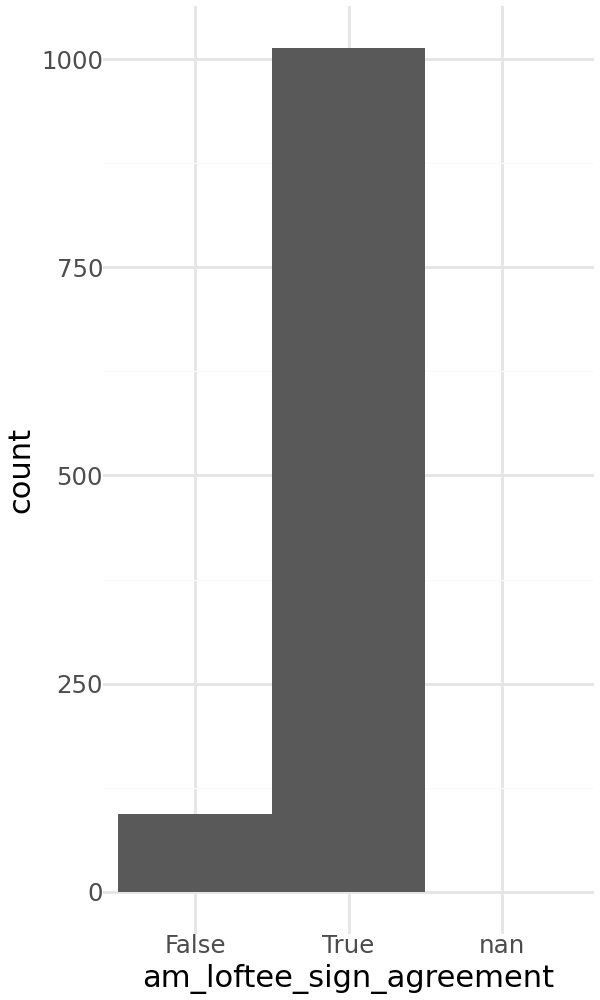

In [25]:
(
    ggplot(gb_plof, aes(x='am_loftee_sign_agreement')) +
    geom_histogram(bins=3) +
    theme_minimal() +
    theme(figure_size=(3, 5))
)

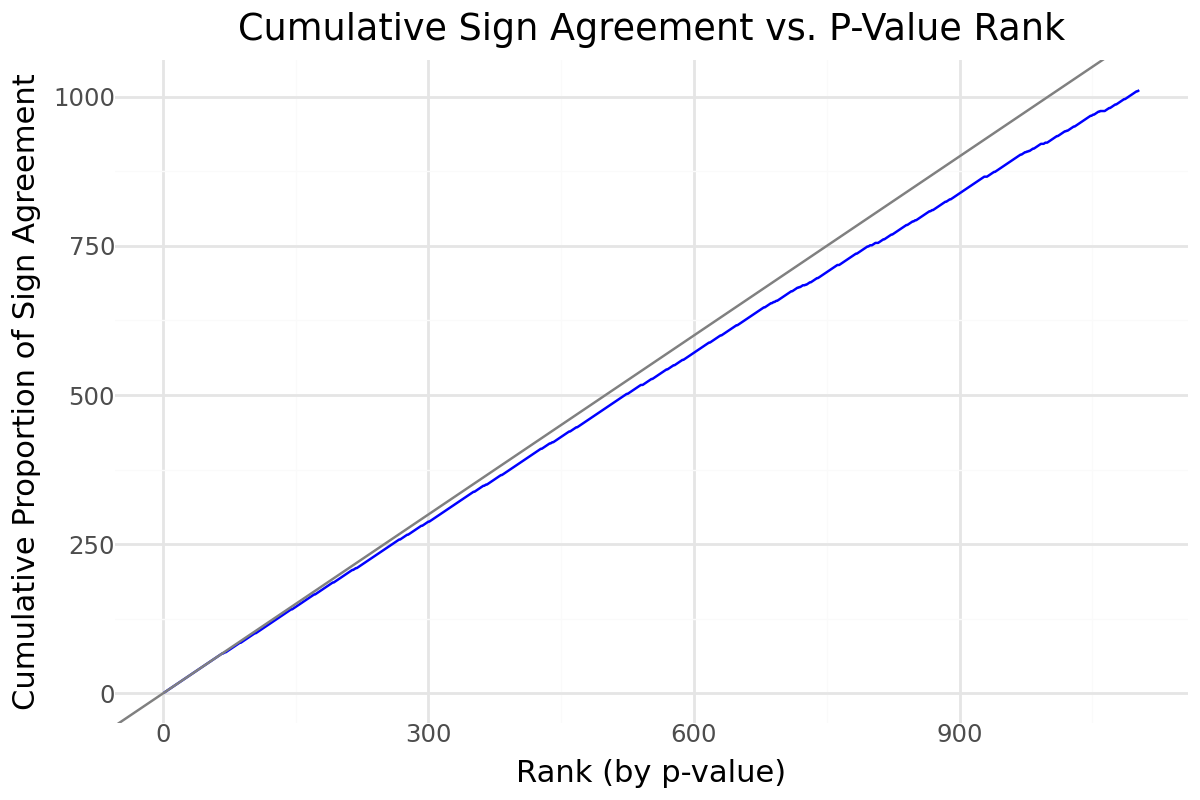

In [26]:
# prepare data
agg_df = (
    gb_plof
    # .select(['min_pvalue_skato', 'sign_agreement'])
    .select(['Pvalue_Burden', 'am_loftee_sign_agreement'])
    .drop_nulls()
    # .sort('min_pvalue_skato')
    .sort('Pvalue_Burden')
    .with_columns(
        rank = pl.int_range(1, pl.len() + 1),
        cum_agreement = pl.col('am_loftee_sign_agreement').cast(pl.Int32).cum_sum()
    )
)

(
    ggplot(agg_df, aes(x='rank', y='cum_agreement')) +
    geom_line(color='blue') +
    geom_abline(color='gray') +
    labs(
        x='Rank (by p-value)',
        y='Cumulative Proportion of Sign Agreement',
        title='Cumulative Sign Agreement vs. P-Value Rank'
    ) +
    theme_minimal() +
    theme(figure_size=(6, 4))
)

In [28]:
gb_plof.filter((pl.col('am_loftee_sign_agreement')==0) | (pl.col('loftee_sign_agreement')==0))

region,gene_name,phenotype,trait_type,annotation,Pvalue,Pvalue_Burden,beta,n_variants,n_plof,n_variants_nonull,am_loftee_corr,loftee_corr,n_individuals_var,n_individuals_plof,plof_prop,am_loftee_prop,t_stat,p_value,am_loftee_sign_agreement,loftee_sign_agreement,am_lof_lof_sign_agreement
str,str,str,str,str,f64,f64,f64,u64,i64,u64,f32,f32,list[u32],list[u32],f64,list[f64],f64,f64,bool,bool,bool
"""ENSG00000068976""","""PYGM""","""lymphocyte_percentage_int""","""continuous""","""pLoF""",1.6918e-9,2.1923e-8,-0.035139,771,51,771,-0.01934,0.031337,"[681, 665, … 1]","[89, 50, … 1]",0.066148,"[0.883268, 0.862516, … 0.001297]",-0.536426,0.591819,true,false,false
"""ENSG00000173575""","""CHD2""","""lymphocyte_percentage_int""","""continuous""","""pLoF""",1.2936e-11,9.3355e-11,-0.020808,957,17,957,0.072932,0.280234,"[683, 510, … 1]","[510, 2, … 1]",0.017764,"[0.713689, 0.532915, … 0.001045]",2.259849,0.024055,false,false,true
"""ENSG00000105122""","""RASAL3""","""lymphocyte_percentage_int""","""continuous""","""pLoF""",3.8530e-10,3.1563e-9,-0.223188,810,63,810,-0.006124,0.005004,"[335, 331, … 1]","[77, 52, … 1]",0.077778,"[0.41358, 0.408642, … 0.001235]",-0.174076,0.861849,true,false,false
"""ENSG00000124875""","""CXCL6""","""lymphocyte_percentage_int""","""continuous""","""pLoF""",7.9007e-12,1.3788e-12,-0.060244,116,9,116,0.057443,0.052137,"[63, 38, … 1]","[6, 3, … 1]",0.077586,"[0.543103, 0.327586, … 0.008621]",0.614337,0.540217,false,false,true
"""ENSG00000129173""","""E2F8""","""red_blood_cell_erythrocyte_cou…","""continuous""","""pLoF""",8.6520e-14,1.3881e-10,-0.101886,549,36,549,0.059389,0.102538,"[581, 361, … 1]","[162, 17, … 1]",0.065574,"[1.058288, 0.657559, … 0.001821]",1.391442,0.164657,false,false,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000054219""","""LY75""","""mean_platelet_thrombocyte_volu…","""continuous""","""pLoF""",6.3883e-8,7.6148e-7,0.0771579,1153,134,1153,0.000659,-0.00332,"[488, 456, … 1]","[293, 80, … 1]",0.116219,"[0.423244, 0.39549, … 0.000867]",0.022358,0.982167,true,false,false
"""ENSG00000005381""","""MPO""","""monocyte_percentage_int""","""continuous""","""pLoF""",4.5005e-44,1.5106e-44,-0.097981,661,55,661,0.021707,-0.102167,"[315, 282, … 1]","[315, 257, … 1]",0.083207,"[0.476551, 0.426626, … 0.001513]",0.557364,0.577468,false,true,false
"""ENSG00000080031""","""PTPRH""","""monocyte_percentage_int""","""continuous""","""pLoF""",2.1618e-10,1.9220e-10,0.123745,941,85,941,0.02078,-0.003711,"[529, 497, … 1]","[185, 125, … 1]",0.090329,"[0.562168, 0.528162, … 0.001063]",0.636902,0.524344,true,false,false


In [29]:
gb_plof.filter((pl.col('am_loftee_sign_agreement')==0) & (pl.col('loftee_sign_agreement')==0))

region,gene_name,phenotype,trait_type,annotation,Pvalue,Pvalue_Burden,beta,n_variants,n_plof,n_variants_nonull,am_loftee_corr,loftee_corr,n_individuals_var,n_individuals_plof,plof_prop,am_loftee_prop,t_stat,p_value,am_loftee_sign_agreement,loftee_sign_agreement,am_lof_lof_sign_agreement
str,str,str,str,str,f64,f64,f64,u64,i64,u64,f32,f32,list[u32],list[u32],f64,list[f64],f64,f64,bool,bool,bool
"""ENSG00000173575""","""CHD2""","""lymphocyte_percentage_int""","""continuous""","""pLoF""",1.2936e-11,9.3355e-11,-0.020808,957,17,957,0.072932,0.280234,"[683, 510, … 1]","[510, 2, … 1]",0.017764,"[0.713689, 0.532915, … 0.001045]",2.259849,0.024055,false,false,true
"""ENSG00000124875""","""CXCL6""","""lymphocyte_percentage_int""","""continuous""","""pLoF""",7.9007e-12,1.3788e-12,-0.060244,116,9,116,0.057443,0.052137,"[63, 38, … 1]","[6, 3, … 1]",0.077586,"[0.543103, 0.327586, … 0.008621]",0.614337,0.540217,false,false,true
"""ENSG00000129173""","""E2F8""","""red_blood_cell_erythrocyte_cou…","""continuous""","""pLoF""",8.6520e-14,1.3881e-10,-0.101886,549,36,549,0.059389,0.102538,"[581, 361, … 1]","[162, 17, … 1]",0.065574,"[1.058288, 0.657559, … 0.001821]",1.391442,0.164657,false,false,true
"""ENSG00000173250""","""GPR151""","""whole_body_fat_mass_int""","""continuous""","""pLoF""",2.9240e-8,3.6210e-8,0.0421692,339,29,339,-0.05166,-0.006431,"[399, 289, … 1]","[151, 104, … 1]",0.085546,"[1.176991, 0.852507, … 0.00295]",-0.949611,0.34299,false,false,true
"""ENSG00000173250""","""GPR151""","""weight_int""","""continuous""","""pLoF""",1.3744e-7,2.0838e-7,0.0254059,340,29,340,-0.078305,-0.033452,"[404, 296, … 1]","[155, 105, … 1]",0.085294,"[1.188235, 0.870588, … 0.002941]",-1.44406,0.149648,false,false,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000090376""","""IRAK3""","""white_blood_cell_leukocyte_cou…","""continuous""","""pLoF""",1.2501e-7,0.000068,0.167751,444,46,444,-0.060684,-0.040513,"[380, 326, … 1]","[326, 123, … 1]",0.103604,"[0.855856, 0.734234, … 0.002252]",-1.278174,0.201859,false,false,true
"""ENSG00000173535""","""TNFRSF10C""","""white_blood_cell_leukocyte_cou…","""continuous""","""pLoF""",2.8130e-7,3.8672e-7,-0.021118,219,15,219,0.071262,0.101864,"[418, 91, … 1]","[53, 9, … 1]",0.068493,"[1.908676, 0.415525, … 0.004566]",1.05243,0.293773,false,false,true
"""ENSG00000173250""","""GPR151""","""body_mass_index_bmi_int""","""continuous""","""pLoF""",1.4142e-8,3.5233e-8,0.0140842,340,29,340,-0.076486,-0.02584,"[404, 296, … 1]","[155, 105, … 1]",0.085294,"[1.188235, 0.870588, … 0.002941]",-1.410304,0.159369,false,false,true


### Investigate associations with opposite sign

In [27]:
ws_corr = gb_plof.filter(pl.col('am_loftee_sign_agreement')==0).sort('p_value')
ws_corr

region,gene_name,phenotype,trait_type,annotation,Pvalue,Pvalue_Burden,beta,n_variants,n_plof,n_variants_nonull,am_loftee_corr,loftee_corr,n_individuals_var,n_individuals_plof,plof_prop,am_loftee_prop,t_stat,p_value,am_loftee_sign_agreement,loftee_sign_agreement,am_lof_lof_sign_agreement
str,str,str,str,str,f64,f64,f64,u64,i64,u64,f32,f32,list[u32],list[u32],f64,list[f64],f64,f64,bool,bool,bool
"""ENSG00000008710""","""PKD1""","""cystatin_c_int""","""continuous""","""pLoF""",8.5576e-34,1.2225e-34,-0.009605,5903,95,5903,0.164591,0.264549,"[632, 627, … 1]","[94, 23, … 1]",0.016094,"[0.107064, 0.106217, … 0.000169]",12.818351,4.0334e-37,false,false,true
"""ENSG00000008710""","""PKD1""","""creatinine_int""","""continuous""","""pLoF""",1.8469e-30,2.6384e-31,-0.113919,5901,94,5901,0.142621,0.275829,"[632, 628, … 1]","[95, 23, … 1]",0.01593,"[0.1071, 0.106423, … 0.000169]",11.067158,3.4245e-28,false,false,true
"""ENSG00000163631""","""ALB""","""total_bilirubin_int""","""continuous""","""pLoF""",2.2106e-10,6.0246e-10,0.006872,435,36,435,-0.221831,-0.160272,"[672, 569, … 1]","[38, 16, … 1]",0.082759,"[1.544828, 1.308046, … 0.002299]",-4.733956,0.000003,false,false,true
"""ENSG00000129173""","""E2F8""","""mean_reticulocyte_volume_int""","""continuous""","""pLoF""",9.5111e-26,2.0467e-15,0.104988,546,36,546,-0.139769,-0.088144,"[577, 352, … 1]","[161, 17, … 1]",0.065934,"[1.056777, 0.644689, … 0.001832]",-3.292259,0.001058,false,false,true
"""ENSG00000008710""","""PKD1""","""microalbumin_in_urine_int""","""continuous""","""pLoF""",2.5232e-7,7.8534e-8,-0.04077,3800,65,3800,0.05293,0.08529,"[641, 619, … 1]","[33, 6, … 1]",0.017105,"[0.168684, 0.162895, … 0.000263]",3.266532,0.001098,false,false,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000152270""","""PDE3B""","""trunk_fat_percentage_int""","""continuous""","""pLoF""",1.6927e-9,2.0992e-9,0.155561,879,70,879,-0.002573,0.026468,"[406, 261, … 1]","[35, 21, … 1]",0.079636,"[0.461889, 0.296928, … 0.001138]",-0.076205,0.939273,false,true,false
"""ENSG00000110245""","""APOC3""","""albumin_int""","""continuous""","""pLoF""",6.2667e-8,6.3025e-8,0.0677269,293,4,293,-0.004134,-0.009562,"[122, 25, … 1]","[122, 13, … 1]",0.013652,"[0.416382, 0.085324, … 0.003413]",-0.070517,0.943831,false,false,true
"""ENSG00000137198""","""GMPR""","""red_blood_cell_erythrocyte_dis…","""continuous""","""pLoF""",2.9839e-17,5.5360e-18,-0.135289,281,25,281,0.003162,-0.005105,"[469, 374, … 1]","[10, 4, … 1]",0.088968,"[1.669039, 1.330961, … 0.003559]",0.052819,0.957914,false,true,false


In [30]:
ws_corr.with_columns(
    eff_delta = pl.col('am_loftee_corr') - pl.col('beta')
).sort('eff_delta', descending=True)

region,gene_name,phenotype,trait_type,annotation,Pvalue,Pvalue_Burden,beta,n_variants,n_plof,n_variants_nonull,am_loftee_corr,loftee_corr,n_individuals_var,n_individuals_plof,plof_prop,am_loftee_prop,t_stat,p_value,am_loftee_sign_agreement,loftee_sign_agreement,am_lof_lof_sign_agreement,eff_delta
str,str,str,str,str,f64,f64,f64,u64,i64,u64,f32,f32,list[u32],list[u32],f64,list[f64],f64,f64,bool,bool,bool,f64
"""ENSG00000240505""","""TNFRSF13B""","""total_protein_int""","""continuous""","""pLoF""",2.1557e-10,3.4388e-11,-0.496515,270,25,270,0.015849,-0.029589,"[628, 296, … 1]","[168, 93, … 1]",0.092593,"[2.325926, 1.096296, … 0.003704]",0.25949,0.795456,false,true,false,0.512364
"""ENSG00000101435""","""CST9L""","""cystatin_c_int""","""continuous""","""pLoF""",2.1518e-10,5.4183e-11,-0.295119,111,10,111,0.050787,0.158215,"[82, 64, … 1]","[6, 3, … 1]",0.09009,"[0.738739, 0.576577, … 0.009009]",0.53092,0.596554,false,false,true,0.345906
"""ENSG00000062282""","""DGAT2""","""apolipoprotein_a_int""","""continuous""","""pLoF""",2.8753e-8,3.7061e-8,-0.302387,275,23,275,0.016795,0.08577,"[638, 429, … 1]","[429, 14, … 1]",0.083636,"[2.32, 1.56, … 0.003636]",0.277542,0.781574,false,false,true,0.319182
"""ENSG00000125703""","""ATG4C""","""aspartate_aminotransferase_int""","""continuous""","""pLoF""",2.8630e-8,2.5710e-8,-0.236253,330,49,330,0.055098,-0.011961,"[380, 302, … 1]","[207, 183, … 1]",0.148485,"[1.151515, 0.915152, … 0.00303]",0.999382,0.318347,false,true,false,0.291351
"""ENSG00000158747""","""NBL1""","""alkaline_phosphatase_int""","""continuous""","""pLoF""",3.2774e-10,0.000903,-0.26141,155,19,155,0.029011,0.0236,"[171, 49, … 1]","[171, 48, … 1]",0.122581,"[1.103226, 0.316129, … 0.006452]",0.359001,0.720089,false,false,true,0.290421
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000120889""","""TNFRSF10B""","""gamma_glutamyltransferase_int""","""continuous""","""pLoF""",9.6335e-10,7.0043e-9,0.186202,359,33,359,-0.043769,-0.03243,"[589, 309, … 1]","[589, 54, … 1]",0.091922,"[1.640669, 0.860724, … 0.002786]",-0.827778,0.408349,false,false,true,-0.229971
"""ENSG00000129173""","""E2F8""","""mean_reticulocyte_volume_int""","""continuous""","""pLoF""",9.5111e-26,2.0467e-15,0.104988,546,36,546,-0.139769,-0.088144,"[577, 352, … 1]","[161, 17, … 1]",0.065934,"[1.056777, 0.644689, … 0.001832]",-3.292259,0.001058,false,false,true,-0.244757
"""ENSG00000125703""","""ATG4C""","""shbg_int""","""continuous""","""pLoF""",5.7846e-10,7.5768e-10,0.242188,314,48,314,-0.030727,-0.039651,"[349, 276, … 1]","[188, 168, … 1]",0.152866,"[1.111465, 0.878981, … 0.003185]",-0.542999,0.587519,false,false,true,-0.272915


In [21]:
ws_genes = ws_corr['gene_name'].value_counts().join(ws_corr[['gene_name', 'n_variants', 'n_plof', 'plof_prop']], on='gene_name').unique().sort('count', descending=True)
ws_genes

gene_name,count,n_variants,n_plof,plof_prop
str,u64,u64,i64,f64
"""GPR151""",11,339,29,0.085546
"""GPR151""",11,340,29,0.085294
"""E2F8""",5,546,36,0.065934
"""PACC1""",5,275,44,0.16
"""PACC1""",5,277,45,0.162455
…,…,…,…,…
"""SLC7A9""",1,402,31,0.077114
"""ME1""",1,335,37,0.110448
"""DENND2C""",1,646,60,0.092879


In [34]:
ws_corr.sort('Pvalue_Burden').head(10)

region,gene_name,phenotype,trait_type,annotation,Pvalue,Pvalue_Burden,beta,n_variants,n_plof,n_variants_nonull,am_loftee_corr,loftee_corr,n_individuals_var,n_individuals_plof,plof_prop,am_loftee_prop,t_stat,p_value,am_loftee_sign_agreement,loftee_sign_agreement,am_lof_lof_sign_agreement
str,str,str,str,str,f64,f64,f64,u64,i64,u64,f32,f32,list[u32],list[u32],f64,list[f64],f64,f64,bool,bool,bool
"""ENSG00000183718""","""TRIM52""","""age_at_death_int""","""continuous""","""pLoF""",6.0083e-8,null,-0.109676,46,3,46,0.000496,0.11922,"[50, 18, … 1]","[3, 1, 1]",0.065217,"[1.086957, 0.391304, … 0.021739]",0.003293,0.997388,false,false,true
"""ENSG00000005381""","""MPO""","""monocyte_percentage_int""","""continuous""","""pLoF""",4.5005e-44,1.5106e-44,-0.097981,661,55,661,0.021707,-0.102167,"[315, 282, … 1]","[315, 257, … 1]",0.083207,"[0.476551, 0.426626, … 0.001513]",0.557364,0.577468,false,true,false
"""ENSG00000110245""","""APOC3""","""red_blood_cell_erythrocyte_dis…","""continuous""","""pLoF""",2.3485e-41,3.3549e-42,0.325066,310,4,310,-0.046317,0.001536,"[135, 27, … 1]","[135, 13, … 1]",0.012903,"[0.435484, 0.087097, … 0.003226]",-0.81374,0.416423,false,true,false
"""ENSG00000008710""","""PKD1""","""cystatin_c_int""","""continuous""","""pLoF""",8.5576e-34,1.2225e-34,-0.009605,5903,95,5903,0.164591,0.264549,"[632, 627, … 1]","[94, 23, … 1]",0.016094,"[0.107064, 0.106217, … 0.000169]",12.818351,4.0334e-37,false,false,true
"""ENSG00000008710""","""PKD1""","""creatinine_int""","""continuous""","""pLoF""",1.8469e-30,2.6384e-31,-0.113919,5901,94,5901,0.142621,0.275829,"[632, 628, … 1]","[95, 23, … 1]",0.01593,"[0.1071, 0.106423, … 0.000169]",11.067158,3.4245e-28,false,false,true
"""ENSG00000179218""","""CALR""","""platelet_distribution_width_in…","""continuous""","""pLoF""",2.4146e-40,2.2187e-24,0.0253034,624,22,624,-0.043694,0.05965,"[353, 283, … 1]","[22, 17, … 1]",0.035256,"[0.565705, 0.453526, … 0.001603]",-1.090766,0.275798,false,true,false
"""ENSG00000168065""","""SLC22A11""","""urate_int""","""continuous""","""pLoF""",1.7850e-20,2.5501e-21,0.051129,464,27,464,-0.111025,-0.049946,"[506, 333, … 1]","[9, 5, … 1]",0.05819,"[1.090517, 0.717672, … 0.002155]",-2.401242,0.016734,false,false,true
"""ENSG00000112787""","""FBRSL1""","""lymphocyte_count_int""","""continuous""","""pLoF""",2.1526e-21,1.4091e-19,-0.053298,1244,58,1244,0.04411,0.097923,"[705, 402, … 1]","[397, 36, … 1]",0.046624,"[0.56672, 0.323151, … 0.000804]",1.556023,0.119957,false,false,true
"""ENSG00000129173""","""E2F8""","""mean_corpuscular_volume_int""","""continuous""","""pLoF""",3.3250e-29,4.7070e-18,0.124069,549,36,549,-0.087576,-0.086486,"[581, 361, … 1]","[162, 17, … 1]",0.065574,"[1.058288, 0.657559, … 0.001821]",-2.056124,0.040245,false,false,true


## Single gene plots

### Single gene plot from appv

Pearson r: -0.04631734639406204, p-value: 0.416422939259117


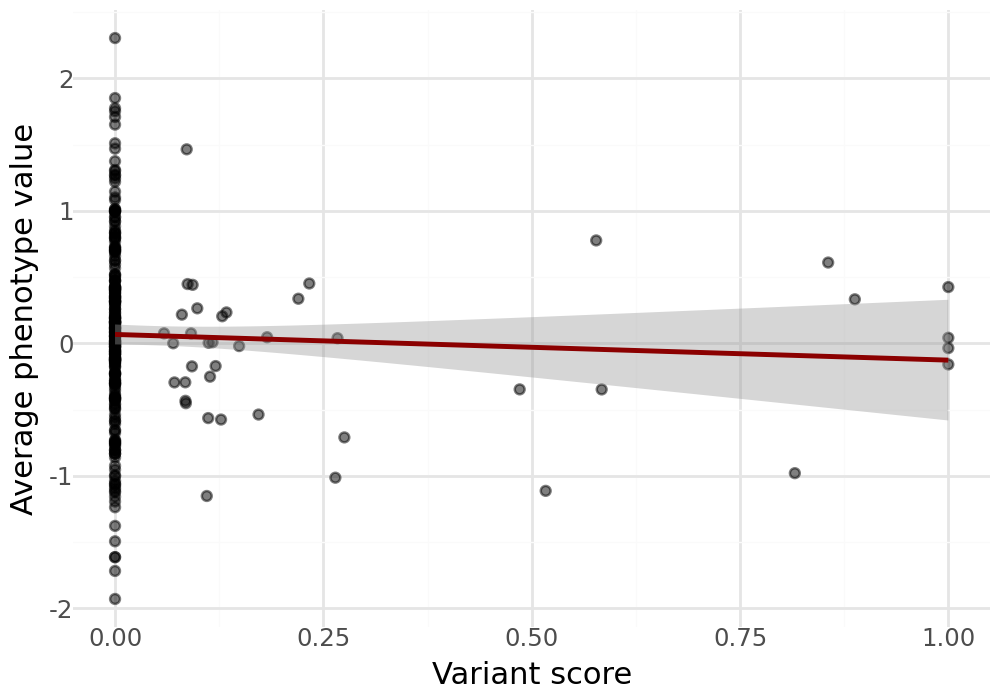

In [42]:
method = 'pearson'
# gene_name = 'TMEM102'
# phenotype = 'shbg_int'
gene_name = "APOC3"
phenotype = "red_blood_cell_erythrocyte_distribution_width_int"

alof = pl.read_parquet("/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag/annotations.parquet", columns=['id', 'region', 'loftee_hc', 'am_pathogenicity']).with_columns(
    am_loftee = (pl.col('loftee_hc') + pl.col('am_pathogenicity')).cast(pl.Float32)
)

# Filter your main dataframe
sc_df = alof_gp.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name)
).drop_nulls(subset=['am_loftee', 'mean_pheno_value'])

lof0 = sc_df.filter(pl.col('loftee_hc') == 0).shape[0]
lof1 = sc_df.filter(pl.col('loftee_hc') == 1).shape[0]

# Check if enough data remains for calculation
if len(sc_df) >= 2:
    pearson_r, pearson_p = stats.pearsonr(
        sc_df['am_loftee'], 
        sc_df['mean_pheno_value']
    )
else:
    pearson_r, pearson_p = np.nan, np.nan

print(f"Pearson r: {pearson_r}, p-value: {pearson_p}")
# Scatter plot
(
    ggplot(sc_df, aes(x='am_loftee', y='mean_pheno_value')) +
    geom_point(alpha=0.5) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x='Variant score',
        y="Average phenotype value",
        # title=f"{gene_name} ({lof1}/{lof0} plof variants)"
    ) +
    theme(figure_size=(5, 3.5))
)

In [36]:
sc_df.filter(pl.col('am_loftee') > 0).sort('n_individuals', descending=True)

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,region,loftee_hc,am_pathogenicity,am_loftee,gene_name
str,str,u32,f32,f32,str,i8,f64,f32,str
"""chr11:116830637:C:T""","""red_blood_cell_erythrocyte_dis…",135,0.424948,0.747845,"""ENSG00000110245""",1,0.0,1.0,"""APOC3"""
"""chr11:116830787:G:A""","""red_blood_cell_erythrocyte_dis…",27,-0.020609,0.961111,"""ENSG00000110245""",0,0.1489,0.1489,"""APOC3"""
"""chr11:116832859:G:C""","""red_blood_cell_erythrocyte_dis…",24,0.075731,0.840086,"""ENSG00000110245""",0,0.0588,0.0588,"""APOC3"""
"""chr11:116830620:C:T""","""red_blood_cell_erythrocyte_dis…",14,0.264304,0.634558,"""ENSG00000110245""",0,0.0987,0.0987,"""APOC3"""
"""chr11:116832858:A:G""","""red_blood_cell_erythrocyte_dis…",14,-0.295095,0.638509,"""ENSG00000110245""",0,0.0713,0.0713,"""APOC3"""
…,…,…,…,…,…,…,…,…,…
"""chr11:116832831:G:C""","""red_blood_cell_erythrocyte_dis…",1,-0.451878,null,"""ENSG00000110245""",0,0.085,0.085,"""APOC3"""
"""chr11:116832816:A:G""","""red_blood_cell_erythrocyte_dis…",1,-1.014318,null,"""ENSG00000110245""",0,0.2644,0.2644,"""APOC3"""
"""chr11:116832813:G:A""","""red_blood_cell_erythrocyte_dis…",1,1.464723,null,"""ENSG00000110245""",0,0.086,0.086,"""APOC3"""


### Single gene plot from burdens

In [37]:
from anngeno import AnnGeno

# --- 2. Read anngeno and get genotypes ---
ag = AnnGeno('/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag', low_mem=True)

gene_id = sc_df['region'].unique().item()
gdata = ag.get_many_regions([gene_id])[gene_id]
var_scores = gdata['annotations']['loftee_hc'].to_numpy() + gdata['annotations']['am_pathogenicity'].to_numpy()

plof_burdens = pl.DataFrame({
    'individual': ag.samples,
    'burden': gdata['genotypes'].T @ var_scores
})#.filter(pl.col('burden') < 2)

config_path = f'/home/dnanexus/ukbgym/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)
cov_list = config.get("covariates", [])

# --- 2. Read and merge data ---
pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int.parquet'
prs_path = '/home/dnanexus/data_dir/phenotypes/PRS190_EUR_missing20_unique2_int.parquet'
cov_path = '/home/dnanexus/data_dir/phenotypes/250709_quant_phenotypes_covariates_genetic_pcs_prs_corrected.parquet'

pheno_lazy = pl.scan_parquet(pheno_path).select("IID", phenotype).rename({"IID": "individual"}).with_columns(pl.col("individual").cast(pl.String)) # Cast to String
prs_lazy = pl.scan_parquet(prs_path).select("IID", f"{phenotype}_prs").rename({"IID": "individual"}).with_columns(pl.col("individual").cast(pl.String)) # Cast to String
cov_lazy = pl.scan_parquet(cov_path).select("sample", *cov_list).rename({"sample": "individual"})

# Join everything and collect into a pandas DataFrame for the regression
merged_pd = (
    pheno_lazy
    .join(prs_lazy, on="individual", how="inner")
    .join(cov_lazy, on="individual", how="inner")
    .drop_nulls()
    .drop_nans()
    .collect()
    .to_pandas()
)

# --- 3. Compute residuals for the single phenotype ---
# Define the dependent (y) and independent (X) variables
y = merged_pd[phenotype]
X = merged_pd[[f"{phenotype}_prs"] + cov_list]
X = sm.add_constant(X) # Add an intercept

# Fit the linear model and get the residuals
model = sm.OLS(y, X).fit()
residuals = model.resid

# --- 4. Create the final long-format DataFrame ---
# This is the final output, ready for plotting or debugging
p_df = pl.DataFrame({
    "individual": merged_pd["individual"].astype(str),
    "phenotype": phenotype,
    "pheno_value": residuals
})

# 4. Join with gene burdens
plot_gp_df = plof_burdens.join(p_df, on='individual', how='inner')
plot_gp_df

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.


individual,burden,phenotype,pheno_value
str,f64,str,f64
"""3834985""",0.0,"""red_blood_cell_erythrocyte_dis…",-0.04797
"""1649233""",0.0,"""red_blood_cell_erythrocyte_dis…",-0.581907
"""5689749""",0.0,"""red_blood_cell_erythrocyte_dis…",-0.833957
"""1160905""",0.0,"""red_blood_cell_erythrocyte_dis…",1.015355
"""5102203""",0.0,"""red_blood_cell_erythrocyte_dis…",0.019285
…,…,…,…
"""5733954""",0.0,"""red_blood_cell_erythrocyte_dis…",1.087175
"""3923515""",0.0,"""red_blood_cell_erythrocyte_dis…",0.410927
"""3548117""",0.0,"""red_blood_cell_erythrocyte_dis…",0.096015


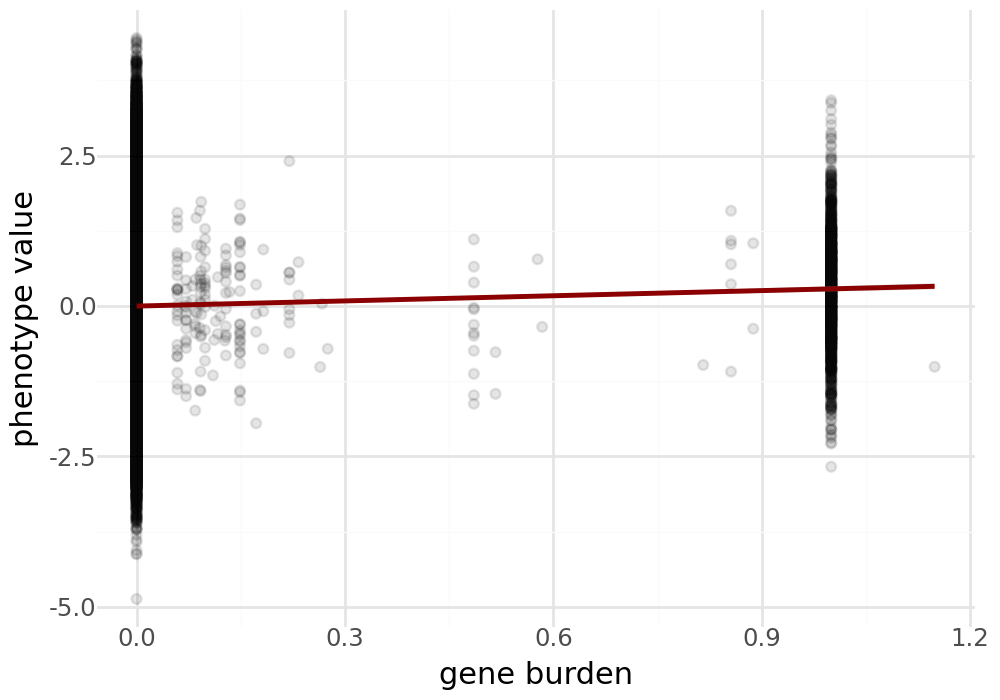

In [41]:
(
    ggplot(plot_gp_df, aes(x='burden', y='pheno_value')) +
    geom_point(alpha=0.1) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x='gene burden',
        y="phenotype value",
        # title=f"{gene_name} ({plot_gp_df['burden'].sum()}/{plot_gp_df.shape[0]} plof)"
    ) +
    theme(figure_size=(5, 3.5))
)